# 1. Vibration Anomaly Detection for Rotating Machinery
### Level: Beginner | Data: Sensor (accelerometer) | Task: Unsupervised anomaly detection

**Industrial context.** Bearings, gearboxes, pumps, and motors are monitored with
accelerometers. A developing fault (e.g., a spall on a bearing race) produces
periodic impacts that change the vibration signature long before the machine fails.
Catching this early avoids unplanned downtime.

**What you'll learn**

1. Simulate healthy vs. faulty vibration signals
2. Inspect them in the time domain and frequency domain (FFT)
3. Extract classic condition-monitoring features (RMS, kurtosis, crest factor, band energy)
4. Train an **Isolation Forest** on *healthy data only* and detect faults it has never seen

> The unsupervised setup mirrors reality: factories have lots of healthy data and very few labeled failures.

**Requirements:** `numpy scipy scikit-learn matplotlib`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy.stats import kurtosis

rng = np.random.default_rng(42)
FS = 12_000          # sampling rate (Hz) - typical for bearing monitoring
DURATION = 1.0       # seconds per recording
N = int(FS * DURATION)
t = np.arange(N) / FS

## 1. Simulate the sensor data

A **healthy** machine shows the shaft rotation frequency plus harmonics and broadband noise.
A **faulty bearing** adds repetitive impacts at the *fault frequency* (here ~107 Hz, a typical
outer-race fault frequency). Each impact rings the structure at a high resonance frequency (~3 kHz)
and decays quickly - this impulsive character is exactly what features like kurtosis pick up.

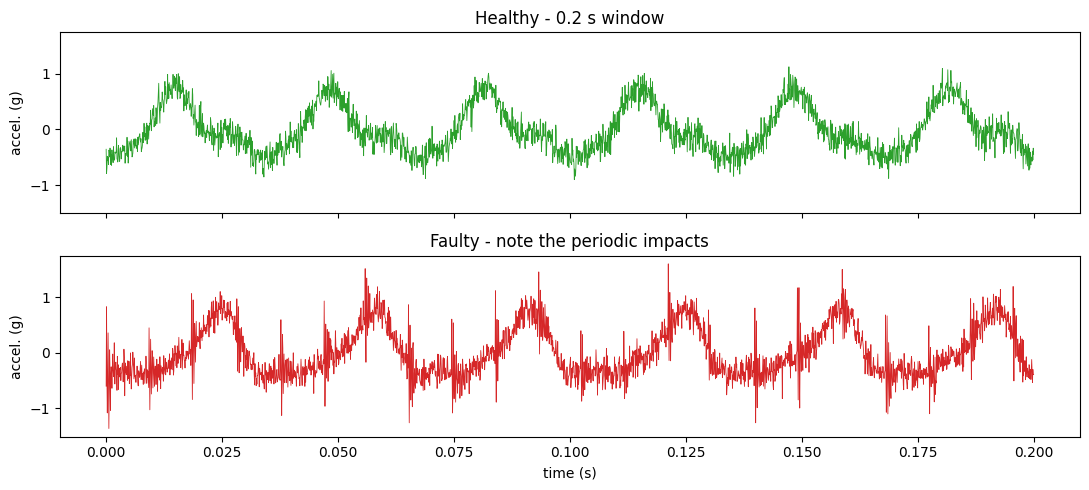

In [2]:
SHAFT_HZ = 29.95        # shaft speed ~1800 RPM
FAULT_HZ = 107.3        # bearing outer-race fault frequency
RESONANCE_HZ = 3000     # structural resonance excited by impacts

def healthy_signal():
    x = 0.5 * np.sin(2*np.pi*SHAFT_HZ*t + rng.uniform(0, 2*np.pi))
    x += 0.2 * np.sin(2*np.pi*2*SHAFT_HZ*t + rng.uniform(0, 2*np.pi))   # 2nd harmonic
    x += 0.1 * np.sin(2*np.pi*3*SHAFT_HZ*t + rng.uniform(0, 2*np.pi))   # 3rd harmonic
    x += rng.normal(0, 0.15, N)                                          # broadband noise
    return x

def faulty_signal(severity=1.0):
    x = healthy_signal()
    # add an exponentially-decaying resonance "ring" at every impact
    base_times = np.arange(0, DURATION, 1/FAULT_HZ)
    impact_times = base_times + rng.normal(0, 2e-4, len(base_times))   # slight timing jitter
    ring_len = int(0.004 * FS)                          # 4 ms ring-down
    for ti in impact_times:
        idx = int(ti * FS)
        if idx < 0 or idx + ring_len >= N:
            continue
        tau = np.arange(ring_len) / FS
        ring = severity * rng.uniform(0.7, 1.3) * np.exp(-tau/0.0008) * np.sin(2*np.pi*RESONANCE_HZ*tau)
        x[idx:idx+ring_len] += ring
    return x

x_h, x_f = healthy_signal(), faulty_signal()

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True, sharey=True)
axes[0].plot(t[:2400], x_h[:2400], lw=0.6, color='tab:green'); axes[0].set_title('Healthy - 0.2 s window')
axes[1].plot(t[:2400], x_f[:2400], lw=0.6, color='tab:red');   axes[1].set_title('Faulty - note the periodic impacts')
axes[1].set_xlabel('time (s)'); [ax.set_ylabel('accel. (g)') for ax in axes]
plt.tight_layout(); plt.show()

## 2. Look at the frequency domain

The impacts spread energy into a band around the 3 kHz resonance - invisible in a casual
time-domain glance at low severity, obvious in the spectrum. This is why frequency-domain
features are the bread and butter of vibration analysis.

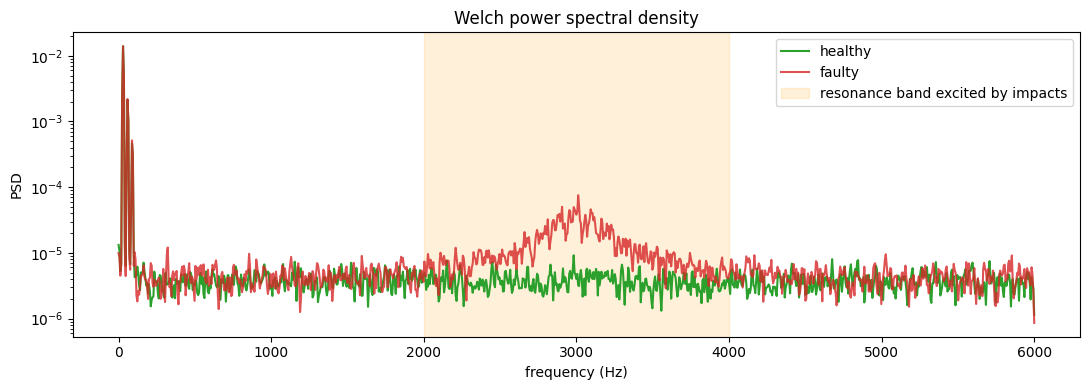

In [3]:
def spectrum(x):
    f, Pxx = sps.welch(x, FS, nperseg=2048)
    return f, Pxx

f, P_h = spectrum(x_h)
_, P_f = spectrum(x_f)

plt.figure(figsize=(11, 4))
plt.semilogy(f, P_h, label='healthy', color='tab:green')
plt.semilogy(f, P_f, label='faulty', color='tab:red', alpha=0.8)
plt.axvspan(2000, 4000, color='orange', alpha=0.15, label='resonance band excited by impacts')
plt.xlabel('frequency (Hz)'); plt.ylabel('PSD'); plt.legend(); plt.title('Welch power spectral density')
plt.tight_layout(); plt.show()

## 3. Feature extraction

Instead of feeding 12,000 raw samples to a model, we compute a handful of features that
condition-monitoring engineers have used for decades:

| Feature | What it captures |
|---|---|
| RMS | overall vibration energy |
| Kurtosis | "impulsiveness" - healthy noise is ~Gaussian (kurtosis ~ 0 excess), impacts push it up |
| Crest factor | peak-to-RMS ratio, also impulsiveness |
| Band energy ratios | where in the spectrum the energy lives |

In [4]:
def extract_features(x):
    rms = np.sqrt(np.mean(x**2))
    kurt = kurtosis(x)
    crest = np.max(np.abs(x)) / rms
    f, Pxx = spectrum(x)
    total = Pxx.sum()
    bands = {'low_0_500': (0, 500), 'mid_500_2k': (500, 2000),
             'res_2k_4k': (2000, 4000), 'high_4k_6k': (4000, 6000)}
    band_feats = [Pxx[(f >= lo) & (f < hi)].sum() / total for lo, hi in bands.values()]
    return [rms, kurt, crest] + band_feats

FEATURE_NAMES = ['rms', 'kurtosis', 'crest', 'E_0-500', 'E_500-2k', 'E_2k-4k', 'E_4k-6k']

# Build a dataset: 300 healthy recordings, 60 faulty at mixed severities
X_healthy = np.array([extract_features(healthy_signal()) for _ in range(300)])
X_faulty  = np.array([extract_features(faulty_signal(severity=s))
                      for s in rng.uniform(0.3, 1.5, 60)])
print('healthy:', X_healthy.shape, ' faulty:', X_faulty.shape)

healthy: (300, 7)  faulty: (60, 7)


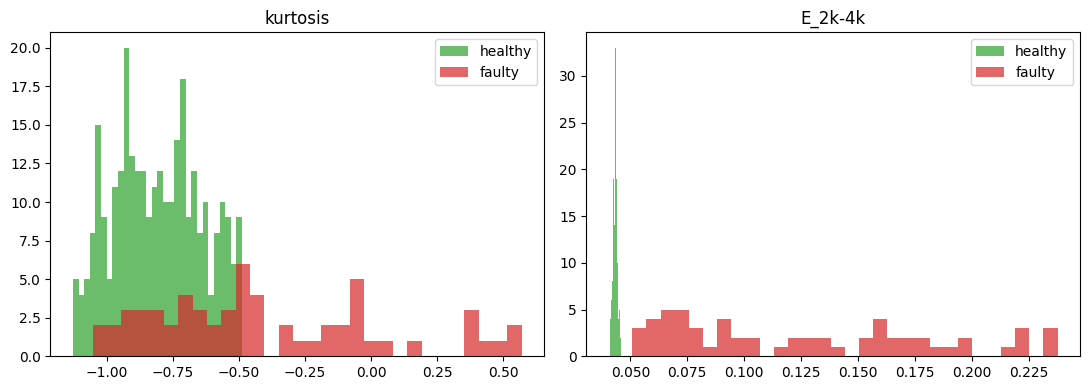

In [5]:
# Quick sanity check: kurtosis and resonance-band energy should already separate the classes
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, [1, 5]):     # kurtosis, E_2k-4k
    ax.hist(X_healthy[:, col], bins=30, alpha=0.7, label='healthy', color='tab:green')
    ax.hist(X_faulty[:, col],  bins=30, alpha=0.7, label='faulty', color='tab:red')
    ax.set_title(FEATURE_NAMES[col]); ax.legend()
plt.tight_layout(); plt.show()

## 4. Train an anomaly detector on healthy data only

`IsolationForest` learns what "normal" looks like. Anything that is easy to isolate
from the normal cloud gets a negative score. We hold out some healthy recordings to
estimate the false-alarm rate honestly.

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

X_train = X_healthy[:220]                      # train on healthy only
X_test  = np.vstack([X_healthy[220:], X_faulty])
y_test  = np.array([0]*80 + [1]*60)            # 0 = healthy, 1 = faulty

model = make_pipeline(
    StandardScaler(),
    IsolationForest(n_estimators=300, contamination=0.02, random_state=0),
)
model.fit(X_train)

pred = (model.predict(X_test) == -1).astype(int)   # -1 = anomaly
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['healthy', 'faulty']))

[[78  2]
 [ 1 59]]
              precision    recall  f1-score   support

     healthy       0.99      0.97      0.98        80
      faulty       0.97      0.98      0.98        60

    accuracy                           0.98       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



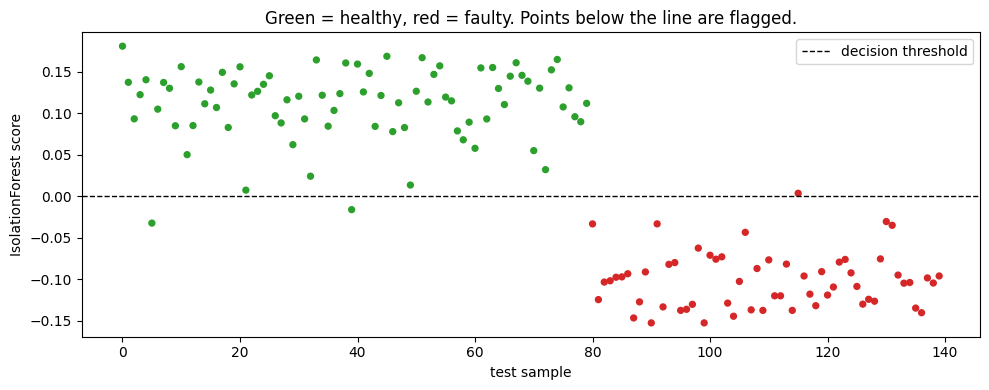

In [7]:
# Anomaly score view: lower = more anomalous
scores = model.decision_function(X_test)
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(len(scores)), scores, c=['tab:green' if y == 0 else 'tab:red' for y in y_test], s=18)
plt.axhline(0, color='k', ls='--', lw=1, label='decision threshold')
plt.xlabel('test sample'); plt.ylabel('IsolationForest score')
plt.title('Green = healthy, red = faulty. Points below the line are flagged.')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Takeaways and next steps

* Good features matter more than fancy models here - kurtosis + band energies made the problem nearly linearly separable.
* Training on healthy data only is the realistic industrial setup (faults are rare and unlabeled).
* **Try it yourself:** lower `severity` toward 0.1 and watch detection degrade; add envelope analysis (Hilbert transform) to recover it.
* **Real data:** the Case Western Reserve University (CWRU) bearing dataset is the standard public benchmark to graduate to.
* Next notebook: predictive maintenance with multivariate sensor streams and *supervised* learning.